# Phase 7 - Evaluation and Result Analysis

This notebook evaluates all saved LightGBM predictions, compares aggregate and per-class metrics, and reviews minority-class behavior.

In [1]:
# Cell 1 - Locate the project root and import evaluation dependencies.
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

project_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'configs' / 'config.yaml').exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: e:\Paper Multiclass-Intrusion-Detection-System


In [2]:
# Cell 2 - Load shared configuration and verify Phase 6 prediction artifacts.
from src.data_loading import load_config, resolve_project_path

config_path = project_root / 'configs' / 'config.yaml'
config = load_config(config_path)
processed_dir = resolve_project_path(config['paths']['processed_dir'], project_root)
metrics_dir = resolve_project_path(config['paths']['metrics_dir'], project_root)
figures_dir = resolve_project_path(config['paths']['figures_dir'], project_root)
scenarios = config['imbalance']['scenarios']
prediction_paths = [processed_dir / f'y_pred_{scenario}.npy' for scenario in scenarios]
missing_paths = [path for path in prediction_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Missing Phase 6 predictions: {missing_paths}')

print(f'Prediction artifacts ready: {len(prediction_paths)}')

Prediction artifacts ready: 4


In [3]:
# Cell 3 - Run the canonical evaluation for all four scenarios.
from src.evaluation import evaluate_all_scenarios

evaluation_result = evaluate_all_scenarios(config_path)
summary = evaluation_result['summary']
display(summary)

,scenario,accuracy,macro_precision,macro_recall,macro_f1,training_seconds,prediction_seconds
0,s1_none,0.843600,0.320398,0.337571,0.314168,104.975497,10.831626
1,s2_class_weight,0.728500,0.410582,0.562000,0.424949,104.912774,10.577099
2,s3_upsampling,0.727819,0.410291,0.557990,0.423284,532.179907,12.209939
3,s4_downsampling,0.615504,0.305047,0.490024,0.292287,1.636508,13.964128


In [4]:
# Cell 4 - Cross-check aggregate results against independently reviewed values.
review_reference = {
    's1_none': {'accuracy': 0.8436, 'macro_f1': 0.3142, 'macro_recall': 0.3376},
    's2_class_weight': {'accuracy': 0.7285, 'macro_f1': 0.4249, 'macro_recall': 0.5620},
    's3_upsampling': {'accuracy': 0.7278, 'macro_f1': 0.4233, 'macro_recall': 0.5580},
    's4_downsampling': {'accuracy': 0.6155, 'macro_f1': 0.2923, 'macro_recall': 0.4900},
}
for scenario, expected_metrics in review_reference.items():
    actual = summary[summary['scenario'] == scenario].iloc[0]
    for metric, expected in expected_metrics.items():
        assert round(float(actual[metric]), 4) == expected, (scenario, metric)

assert summary.loc[summary['macro_f1'].idxmax(), 'scenario'] == 's2_class_weight'
assert summary.loc[summary['macro_recall'].idxmax(), 'scenario'] == 's2_class_weight'
print('Aggregate metrics match the independent review values.')

Aggregate metrics match the independent review values.


In [5]:
# Cell 5 - Compare precision, recall, and F1 for the five minority-focus classes.
minority = evaluation_result['per_class'][
    evaluation_result['per_class']['is_minority_focus']
].copy()
minority_pivot = minority.pivot(
    index='class_name',
    columns='scenario',
    values=['precision', 'recall', 'f1_score'],
)
display(minority_pivot)

minority_means = (
    minority.groupby('scenario')[['precision', 'recall', 'f1_score']]
    .mean()
    .reindex(scenarios)
)
display(minority_means)

precision                                                  recall  \
scenario     s1_none s2_class_weight s3_upsampling s4_downsampling   s1_none   
class_name                                                                     
Backdoor    0.863737        0.964733      0.973319        0.818960  0.937558   
DDoS        0.020833        0.020202      0.000000        0.000988  0.025000   
DoS         0.020134        0.000000      0.014493        0.003241  0.103448   
MITM        0.006897        0.085851      0.078869        0.002965  0.097087   
Ransomware  0.114591        0.582996      0.586533        0.056032  0.157843   

                                                          f1_score  \
scenario   s2_class_weight s3_upsampling s4_downsampling   s1_none   
class_name                                                           
Backdoor          0.992632      0.994474        0.986554  0.899134   
DDoS              0.050000      0.000000        0.100000  0.022727   
DoS               0.000000      0.034483        0.137931  0.033708   
MITM              0.524272      0.514563        0.446602  0.012878   
Ransomware        0.988235      0.973529        0.941176  0.132784   

                                                          
scenario   s2_class_weight s3_upsampling s4_downsampling  
class_name                                                
Backdoor          0.978484      0.983783        0.894979  
DDoS              0.028777      0.000000        0.001956  
DoS               0.000000      0.020408        0.006334  
MITM              0.147541      0.136774        0.005890  
Ransomware        0.733358      0.732031        0.105768

,precision,recall,f1_score
scenario,,,
s1_none,0.205238,0.264187,0.220246
s2_class_weight,0.330756,0.511028,0.377632
s3_upsampling,0.330643,0.503410,0.374599
s4_downsampling,0.176437,0.522453,0.202985


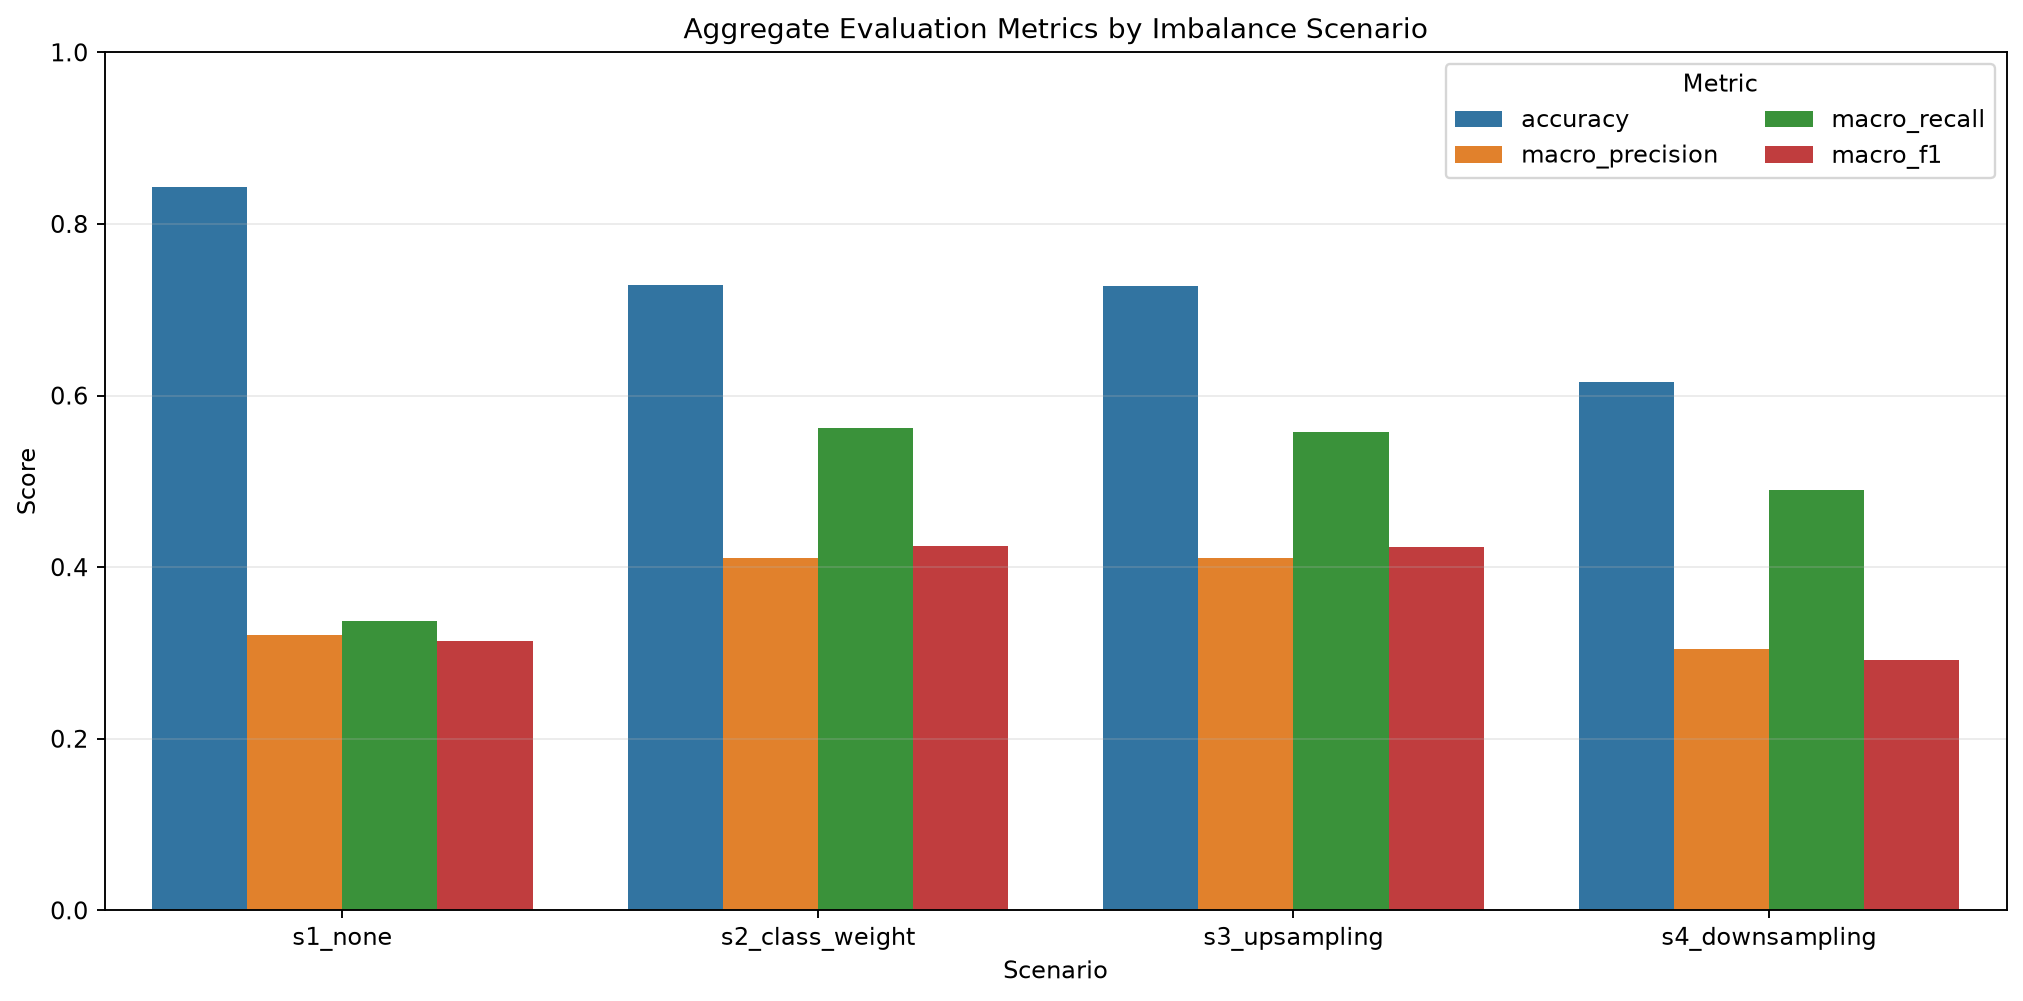

## s1_none

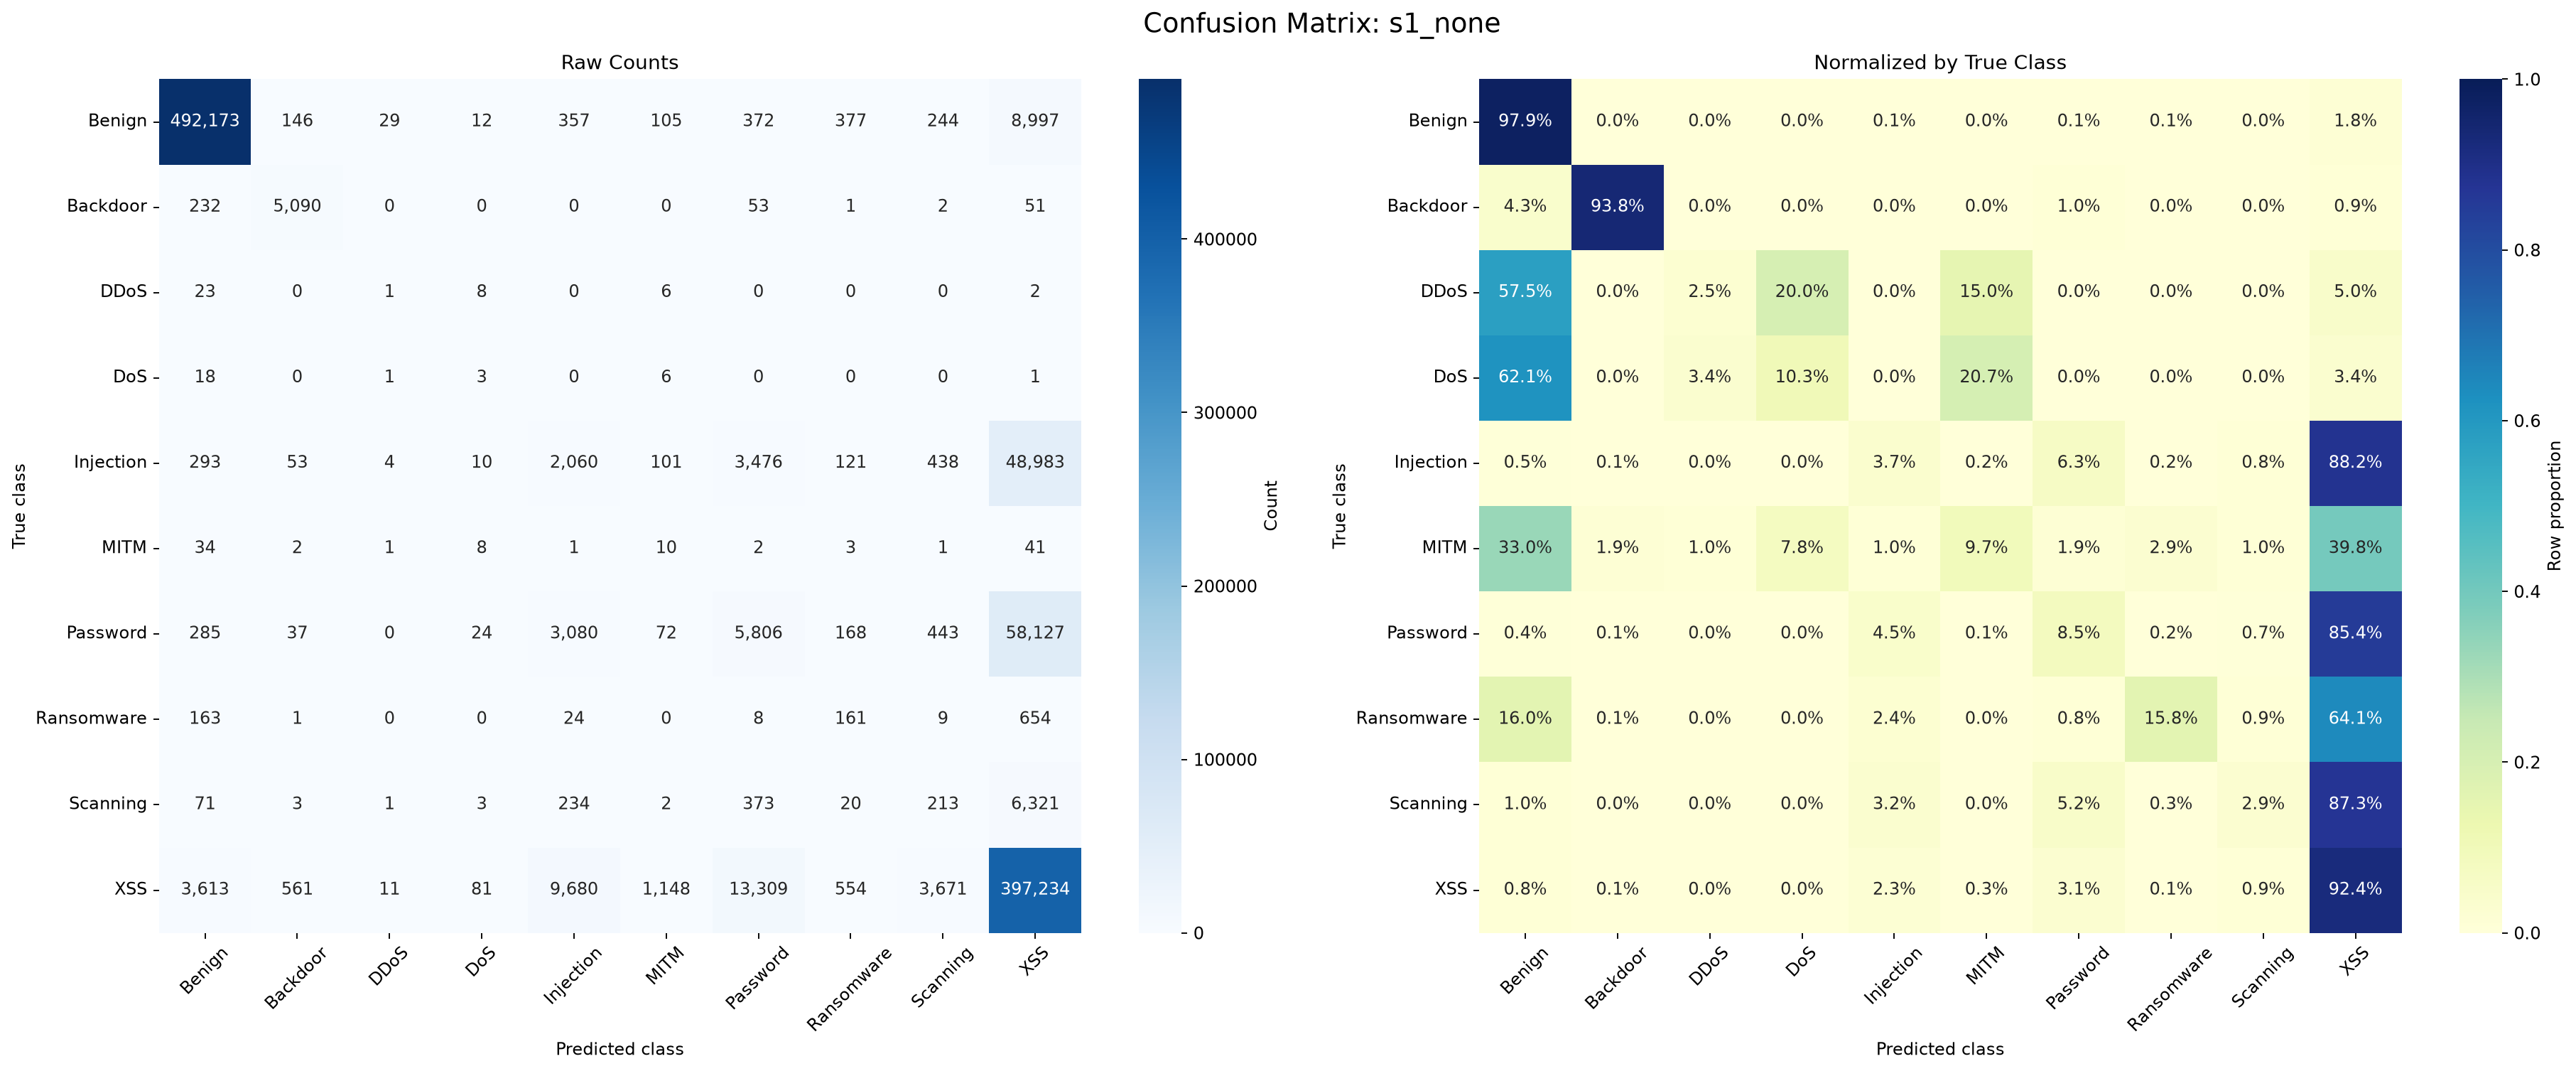

## s2_class_weight

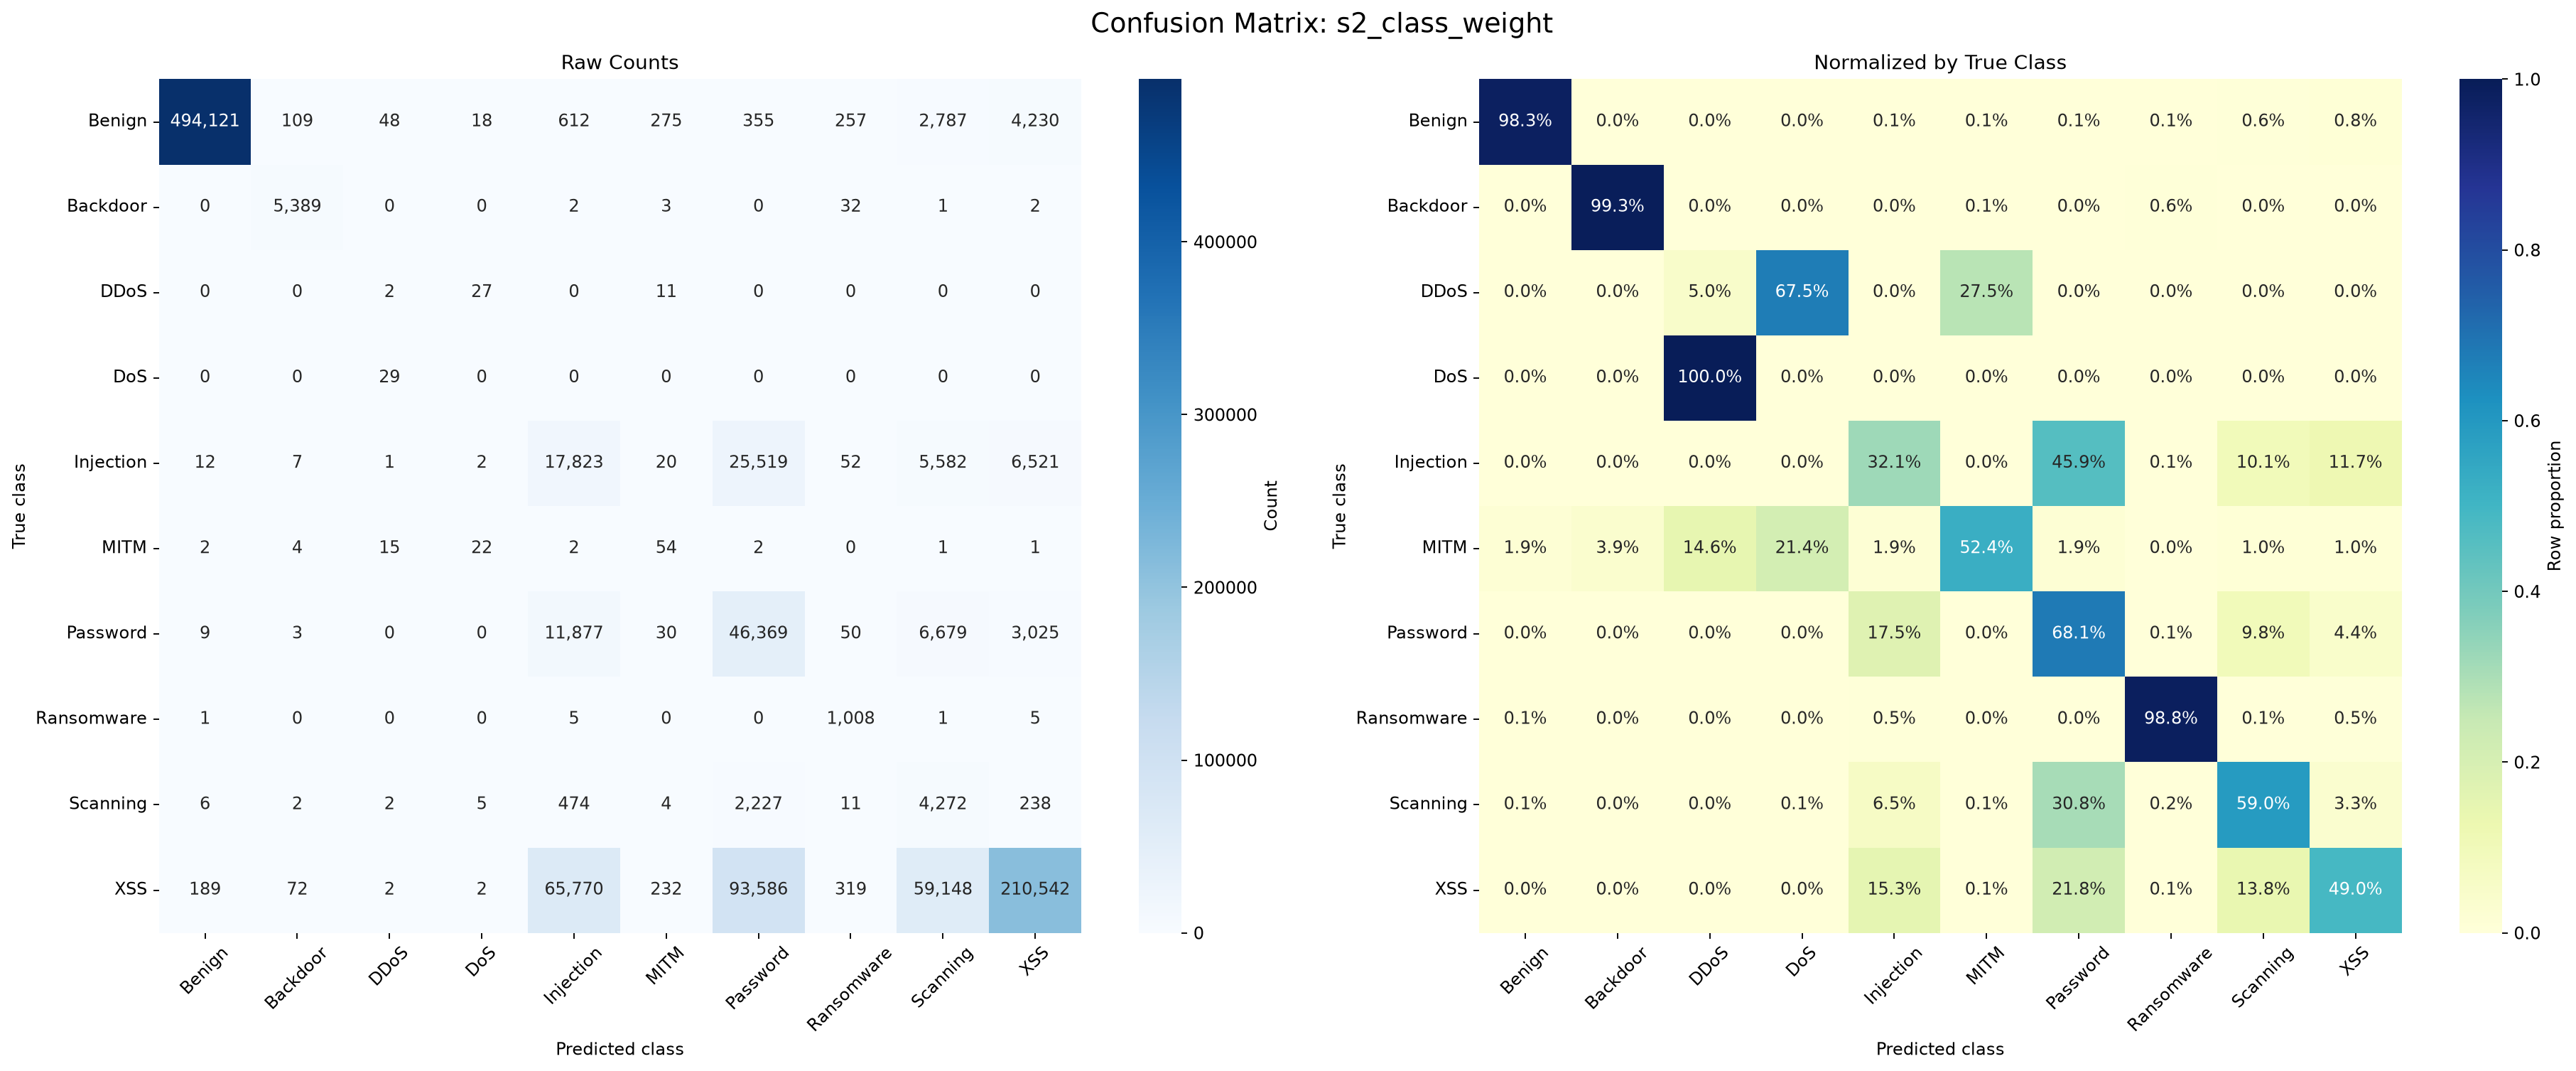

## s3_upsampling

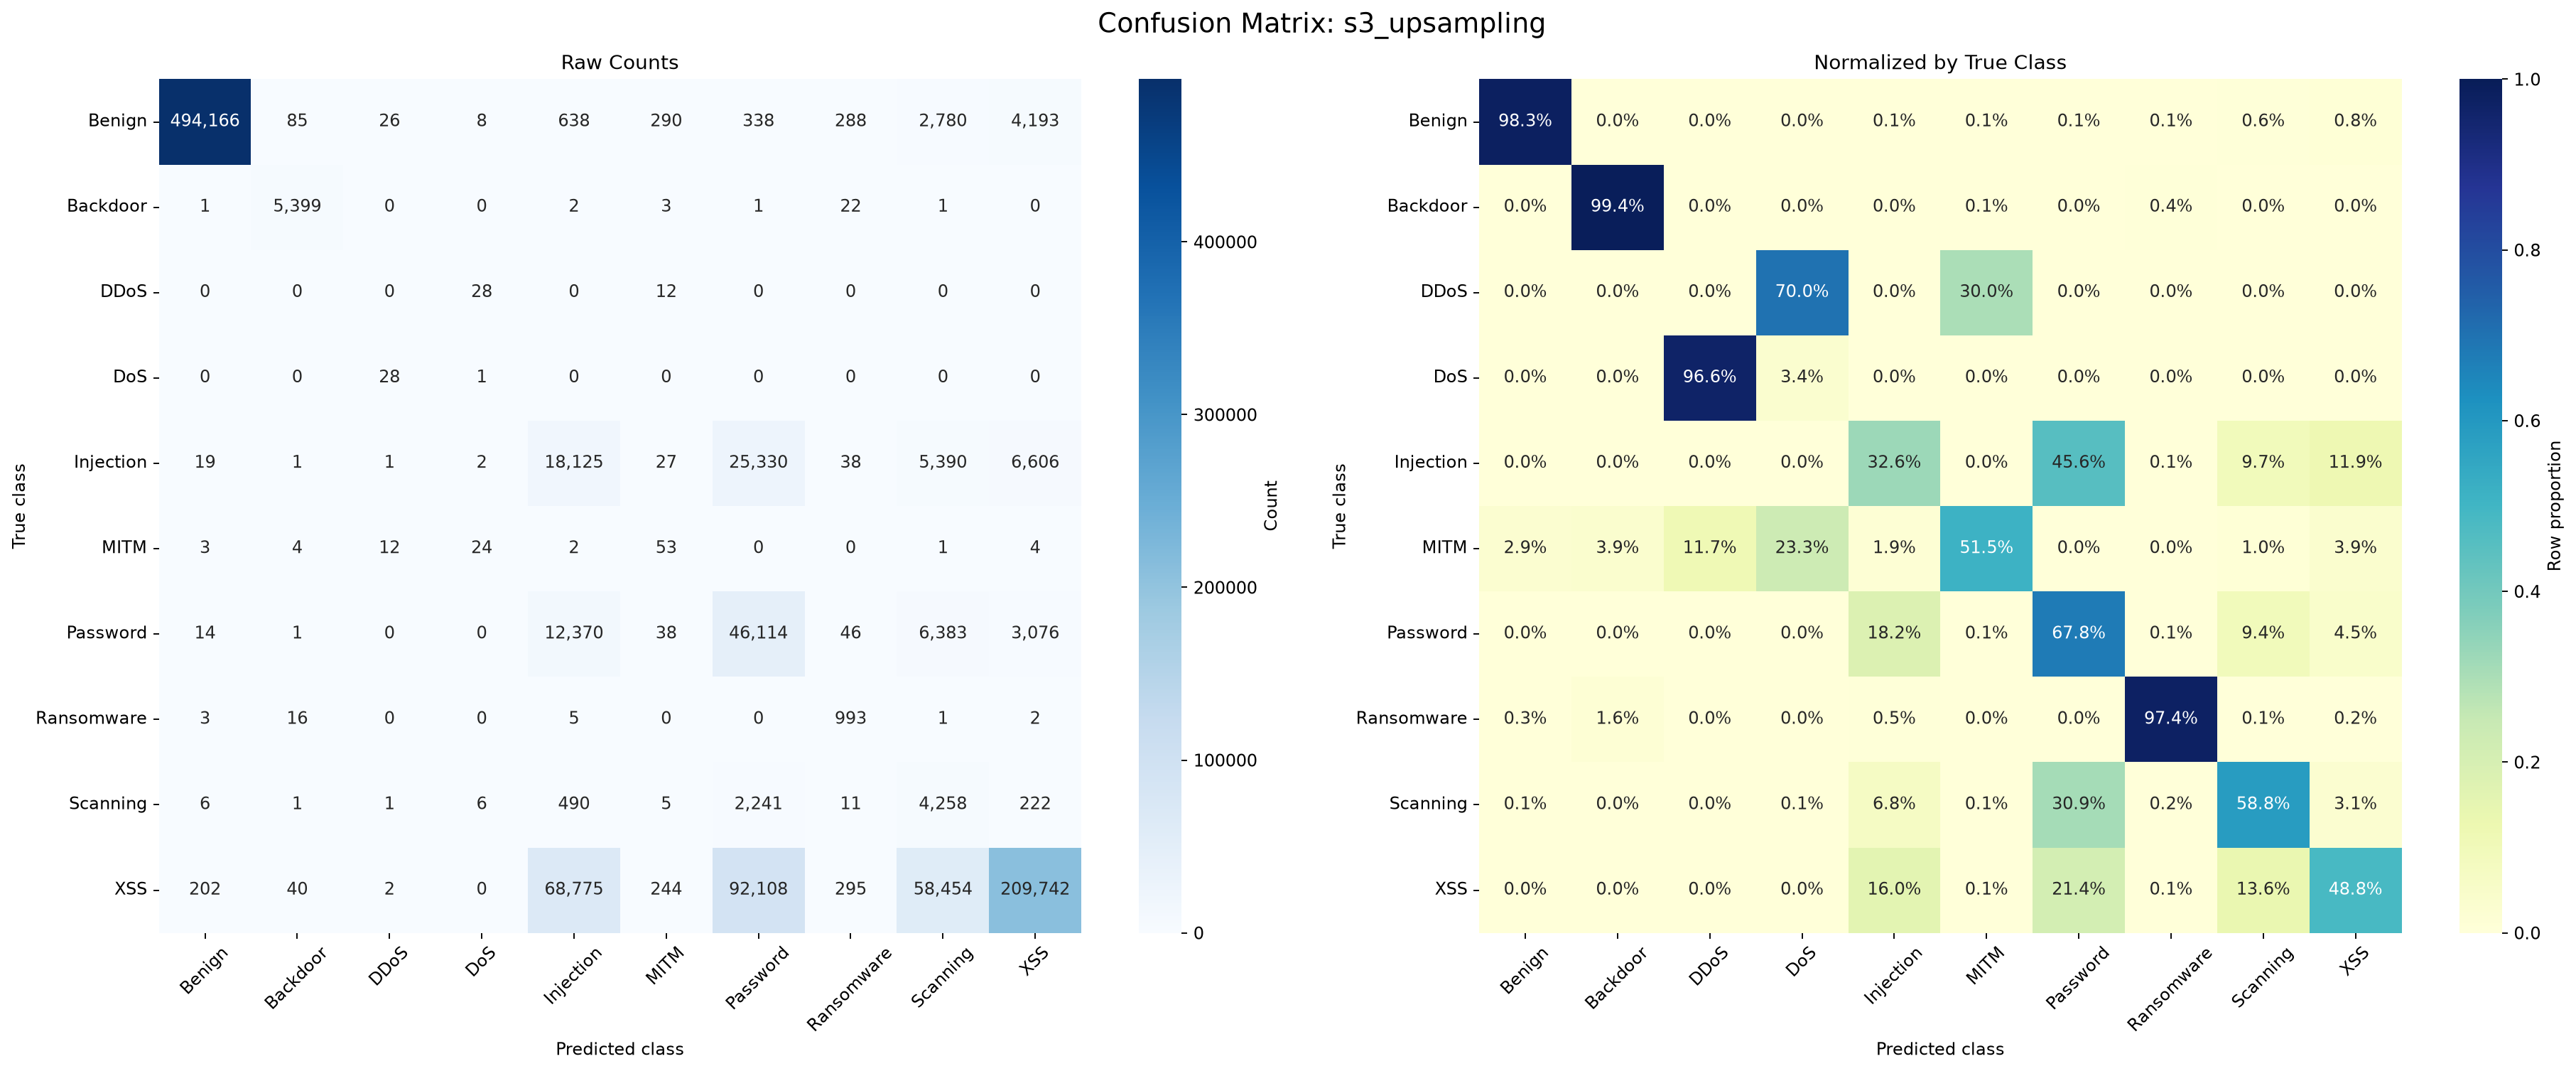

## s4_downsampling

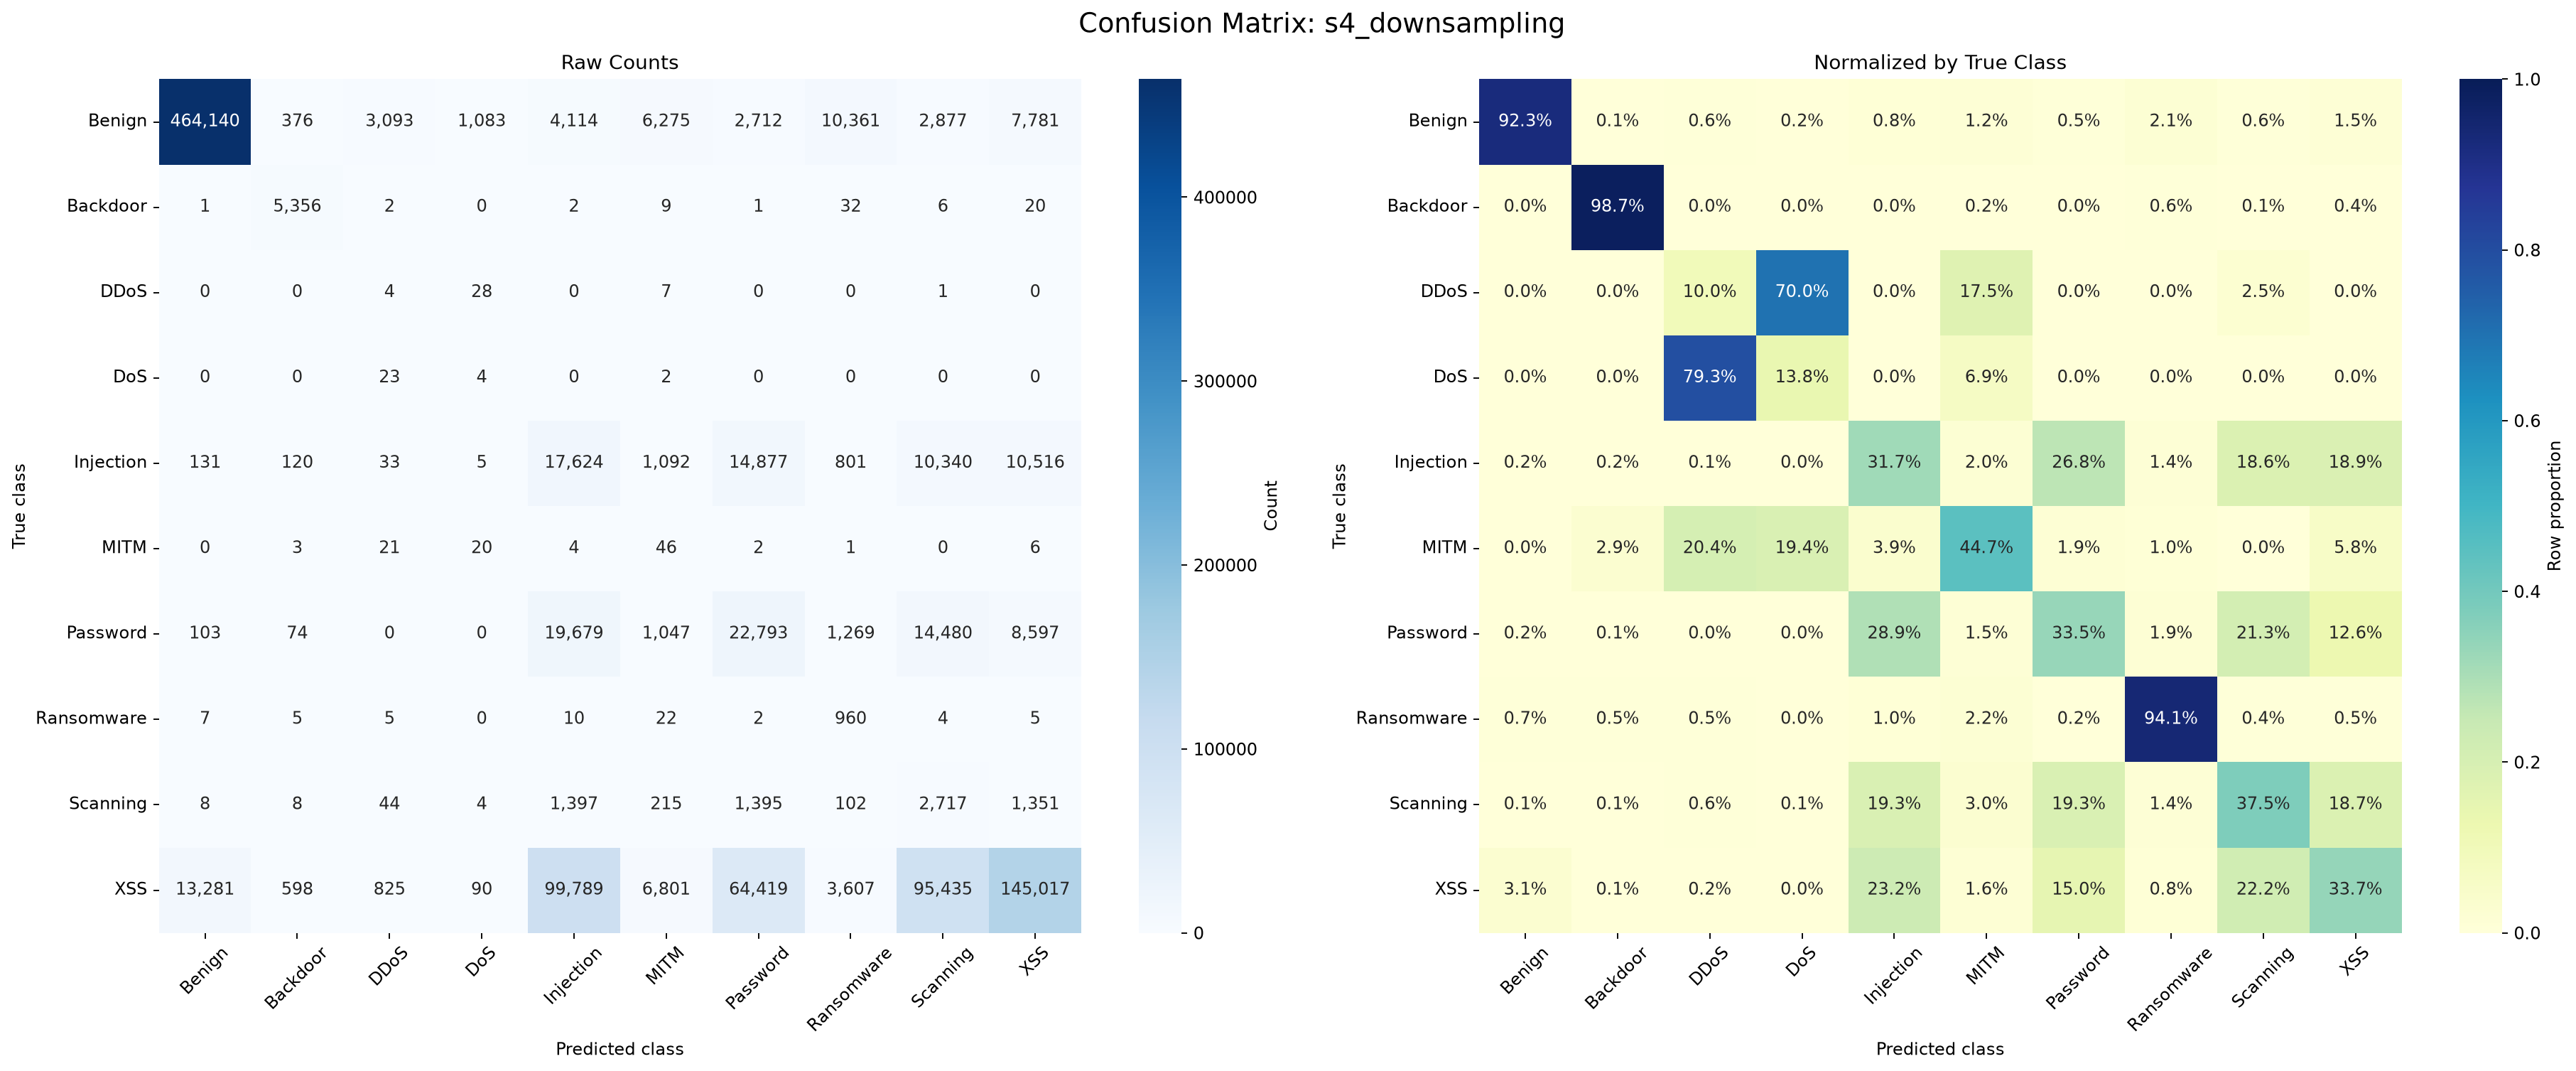

In [6]:
# Cell 6 - Display the aggregate comparison and all confusion-matrix figures.
display(Image(filename=evaluation_result['metric_figure_path']))
for scenario in scenarios:
    figure_path = figures_dir / f'confusion_matrix_{scenario}.png'
    if not figure_path.exists():
        raise FileNotFoundError(figure_path)
    display(Markdown(f'## {scenario}'))
    display(Image(filename=str(figure_path)))

In [7]:
# Cell 7 - Review the generated qualitative findings and methodological interpretation.
analysis = evaluation_result['qualitative_analysis']
for finding in analysis['key_findings']:
    print(f'- {finding}')

equivalence = analysis['s2_s3_equivalence']
print(f"S2-S3 macro F1 delta: {equivalence['macro_f1_absolute_delta']:.6f}")
print(
    'S3/S2 training-time ratio: '
    f"{equivalence['training_time_ratio_s3_over_s2']:.3f}"
)
print(equivalence['explanation'])

- S1 has the highest accuracy (0.8436) but a substantially lower macro F1-score (0.3142) than S2 and S3.
- S2 provides the best aggregate macro recall (0.5620) and macro F1-score (0.4249).
- S2 and S3 differ by only 0.0017 macro F1, which is consistent with their equivalent relative class contribution.
- S4 reaches the highest minority mean recall (0.5225) but low minority mean precision (0.1764) and F1 (0.2030), indicating extensive false positives.
- DoS and DDoS remain the least reliable minority classes across all scenarios; their best per-class F1-scores are 0.0337 and 0.0288, respectively.
S2-S3 macro F1 delta: 0.001665
S3/S2 training-time ratio: 5.073
Random duplication and class weighting give LightGBM the same relative per-class contribution up to a constant global scale. Their similar metrics are therefore an expected experimental finding, not an implementation defect.


In [8]:
# Cell 8 - List the Phase 7 artifacts prepared for result reporting.
artifact_paths = [
    Path(evaluation_result['summary_path']),
    Path(evaluation_result['per_class_path']),
    Path(evaluation_result['minority_path']),
    Path(evaluation_result['qualitative_path']),
    Path(evaluation_result['analysis_markdown_path']),
    Path(evaluation_result['metric_figure_path']),
]
artifact_paths.extend(
    figures_dir / f'confusion_matrix_{scenario}.png' for scenario in scenarios
)
artifact_summary = pd.DataFrame({
    'artifact': [str(path) for path in artifact_paths],
    'exists': [path.exists() for path in artifact_paths],
})
assert artifact_summary['exists'].all()
display(artifact_summary)
print('Phase 7 evaluation artifacts are complete.')

,artifact,exists
0,E:\Paper Multiclass-Intrusion-Detection-System...,True
1,E:\Paper Multiclass-Intrusion-Detection-System...,True
2,E:\Paper Multiclass-Intrusion-Detection-System...,True
3,E:\Paper Multiclass-Intrusion-Detection-System...,True
4,E:\Paper Multiclass-Intrusion-Detection-System...,True
5,E:\Paper Multiclass-Intrusion-Detection-System...,True
6,e:\Paper Multiclass-Intrusion-Detection-System...,True
7,e:\Paper Multiclass-Intrusion-Detection-System...,True
8,e:\Paper Multiclass-Intrusion-Detection-System...,True
9,e:\Paper Multiclass-Intrusion-Detection-System...,True


Phase 7 evaluation artifacts are complete.
